# Plot figures analogue analysis (poster/presentation)

### Packages and Directories

In [1]:
# --- Imports ---
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
from statsmodels.stats.multitest import fdrcorrection
import calendar
from datetime import datetime, timedelta
import cftime
from matplotlib.lines import Line2D

from scipy import ndimage

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Custom Functions ---
# sys.path.append('/home/portal/script/python/precip_Cristina/')                    # tintin
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/precip_Cristina')   # alice
import functions_analogues_PrMax as fanPM
import functions_analogues_LUCAFAMOSS as fan

In [2]:
# Define directories for data and figures
# # tintin
# CERRA_dir = '/work_big/users/clima/portal/CERRA/'
# ERA5_dir = '/work_big/users/clima/portal/ERA5/'
# CRCM5_dir = '/work_big/users/clima/portal/CRCM5-LE/'
# fig_dir = '/home/portal/figures/analogues/'

# alice
CERRA_dir = '/media/alice/Crucial X9/portal/data_CNR/CERRA/'
ERA5_dir = '/media/alice/Crucial X9/portal/data_CNR/ERA5/'
CRCM5_dir = '/media/alice/Crucial X9/portal/data_CNR/CRCM5-LE/'
fig_dir = '/home/alice/Desktop/CNR/ENCIRCLE/materiale_alice/figures/analogues/poster/'
diff_dir = './analogue_data/analogue_differences/'
pr_mask_dir = './analogue_data/pr_in_mask/'

### Parameters

In [3]:
# Variable
var_analogues = 'psl-zg500-std'  # Variable used to find the analogues, e.g. 'psl' for sea level pressure
var_BAM = 'psl'                  # Variable used for the BAM search

# Quantile and analogue number
qtl_LE = 0.99
no_analogues = 18

# Number of ensemble members
no_membs = 49

# List of members
list_membs = [name for name in os.listdir(CRCM5_dir + 'psl') if os.path.isdir(os.path.join(CRCM5_dir + 'psl', name))]
list_membs = sorted(list_membs)[:no_membs]  # Select the first 'no_membs' members


#### Average precipitation in BAM >20mm mask for all events

In [4]:
# Parameters
# Variable
varname = 'pr'
factor = 3600

# List events
list_nodes = [1,3,3,5,5,6]
list_events = [1,3,8,4,23,19]
tot_events = len(list_nodes)

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)

# List of ensemble sizes (by no members considered)
no_membs = 49

In [8]:
# Initialise empty lists for statistics
list_stats_past = []  # List to store statistics for past epochs
list_stats_future = []  # List to store statistics for future epochs
list_ds_reg = []  # List to store difference datasets


for ie in range(tot_events):
    no_node = list_nodes[ie]
    no_event = list_events[ie]
    # BAM regional mean precipitation
    BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)
    mean_pr_BAM_in_mask = BAM_info['precip_in_BAM_20mm_mask'][BAM_index]
    str_event_BAM = f'BAM-node{no_node}-extreme{no_event}-alertregions'

    # Upload analogue data for mean precipitation in BAM mask
    for j in range(no_epochs):
        year_range = list_year_ranges[j]
        str_year_range = "-".join(str(x) for x in year_range)

        # Load analogue values
        pr_reg_epoch = None
        for im, memb in enumerate(list_membs[:no_membs]):
            file = f'{pr_mask_dir}analogues-{var_analogues}_mask-mean-{varname}_{str_event_BAM}_{int(100*qtl_LE)}pct_{str_year_range}_CRCM5_{memb}.nc'
            if not os.path.exists(file):
                print(f'File {file} does not exist. Skipping epoch {j+1}.')
                continue
            pr_reg = xr.open_dataset(file)['pr'].values
            if pr_reg_epoch is None:
                pr_reg_epoch = pr_reg
            else:
                pr_reg_epoch = np.concatenate((pr_reg_epoch, pr_reg))
        list_ds_reg.append(np.array(pr_reg_epoch))

    # Compute p-val using KS test
    arr_past = list_ds_reg[-3].flatten()
    arr_past = arr_past[~np.isnan(arr_past)]
    arr_present = list_ds_reg[-2].flatten()
    arr_present = arr_present[~np.isnan(arr_present)]
    arr_future = list_ds_reg[-1].flatten()
    arr_future = arr_future[~np.isnan(arr_future)]
    list_stats_past.append(fanPM.ks_stat_and_pval(arr_past, arr_present))
    list_stats_future.append(fanPM.ks_stat_and_pval(arr_present, arr_future))

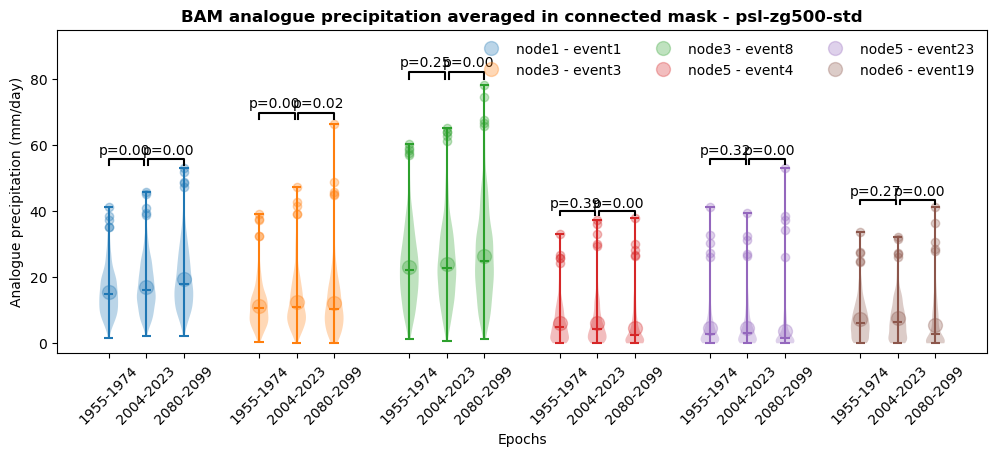

In [9]:
# Plot violin plots per epoch, once per ensemble size

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 4.2))
ax.set_title(f"BAM analogue precipitation averaged in connected mask - {var_analogues}", fontsize=12, weight="bold")

# Violin plot setup
list_epoch_str = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]

for i in range(tot_events):
    # Get the data for the current epoch and ensemble size
    list_reg_precip = list_ds_reg[i*no_epochs:(i+1)*no_epochs]
    # Plot the violin for the current epoch and ensemble size
    reg_precip_clean = [x[~np.isnan(x)]*factor for x in list_reg_precip]
    violin = ax.violinplot(reg_precip_clean, positions=1+i*4+np.arange(no_epochs),showmeans=False, showmedians=True, showextrema=True)
    # Plot the mean precipitation for the epoch
    violin_color = violin['bodies'][0].get_facecolor().flatten()
    plot_label = f'node{list_nodes[i]} - event{list_events[i]}'
    ax.plot(1+i*4+np.arange(no_epochs), [np.mean(reg_precip_clean[j]) for j in range(len(reg_precip_clean))], marker='o', color=violin_color, markersize=10, label=plot_label, linewidth=0)
    # Plot the 5 top values as stars
    for j in range(no_epochs):
        top5_values = np.sort(reg_precip_clean[j])[-5:]
        ax.plot(np.full(top5_values.shape, 1 + i*4 + j), top5_values, marker='o', color=violin_color, markersize=6, linewidth=0)
    
    # Add p-value
    p_past = list_stats_past[i][1]
    p_future = list_stats_future[i][1]
    # Get x positions of the two violins
    x1 = 1 + i*4 + 0           # first violin position
    x2a = 1 + i*4 + 0.95              # second violin position
    x2b = 1 + i*4 + 1.05
    x3 = 1 + i*4 + 2              # third violin position
    y_max = max([np.max(reg_precip_clean[j]) for j in range(no_epochs)])  # highest point for vertical placement
    # Draw a bracket line
    ax.plot([x1, x1, x2a, x2a], [y_max*1.02, y_max*1.05, y_max*1.05, y_max*1.02], color="black")
    ax.plot([x2b, x2b, x3, x3], [y_max*1.02, y_max*1.05, y_max*1.05, y_max*1.02], color="black")
    # Add the p-value text above
    ax.text((3*x1+2*x2b)/5, y_max*1.06, f"p={p_past:.2f}", ha="center", va="bottom", fontsize=10, color="black")
    ax.text((2*x2a+3*x3)/5, y_max*1.06, f"p={p_future:.2f}", ha="center", va="bottom", fontsize=10, color="black")
# Ticks and labels
ax.set_xticks(range(1, tot_events*(no_epochs + 1)))
list_epoch_ticks = []
xticks = []
for i in range(tot_events):
    xticks.extend([1+i*4+j for j in range(no_epochs)])
    list_epoch_ticks.extend(list_epoch_str)
ax.set_ylim(-3,95)
ax.set_xticks(xticks)
ax.set_xticklabels(list_epoch_ticks, rotation=45)
ax.set_xlabel('Epochs')
ax.set_ylabel('Analogue precipitation (mm/day)')
ax.legend(ncol=3, frameon=False, loc='upper right') 
plt.show()

# Save the figure
fig.savefig(f"{fig_dir}{varname}_mask-mean_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_{no_membs}.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{fig_dir}{varname}_mask-mean_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_{no_membs}.pdf", bbox_inches='tight')

#### Average precipitation in town mask for all events

In [5]:
# Parameters
# Variable
varname = 'pr'
factor = 3600

# List events
list_nodes = [1,3,3,5,5,6]
list_events = [1,3,8,4,23,19]
tot_events = len(list_nodes)
town_events = ['Pordenone', 'Genova', 'Genova','Bologna', 'Bologna', 'Bologna']
color_events = ['#0072B2', '#009E73', '#F0E442', '#CC79A7', '#56B4E9', '#D55E00']

# Significance test
stat_tests = ['tW', 'CvM']  # 'KS' for Kolmogorov-Smirnov test, tW for Welch's t-test, AD for Anderson-Darling test, CvM for Cramér-von Mises test

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)
list_epoch_names = ['PAST', 'PRESENT', 'FUTURE']

# List of ensemble sizes (by no members considered)
no_membs = 49

In [6]:
# Initialise empty lists for statistics
list_stats_pastpresent = []  # List to store statistics for past and present epochs
list_stats_pastfuture = []  # List to store statistics for past and future epochs
list_stats_presentfuture = []  # List to store statistics for present and future epochs
list_ds_town = []  # List to store difference datasets


for ie in range(tot_events):
    no_node = list_nodes[ie]
    no_event = list_events[ie]
    # BAM regional mean precipitation
    BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)
    mean_pr_BAM_in_mask = BAM_info['precip_in_town_7x7_land_mask'][BAM_index]
    str_event_BAM = f'BAM-node{no_node}-extreme{no_event}-alertregions'
    town_event = town_events[ie]

    # Upload analogue data for mean precipitation in BAM mask
    for j in range(no_epochs):
        year_range = list_year_ranges[j]
        str_year_range = "-".join(str(x) for x in year_range)

        # Load analogue values
        pr_town_epoch = None
        for im, memb in enumerate(list_membs[:no_membs]):
            file = f'{pr_mask_dir}towns/analogues-{var_analogues}_{town_event}-{varname}_{str_event_BAM}_{int(100*qtl_LE)}pct_{str_year_range}_CRCM5_{memb}.nc'
            if not os.path.exists(file):
                print(f'File {file} does not exist. Skipping epoch {j+1}.')
                continue
            pr_town = xr.open_dataset(file)['pr_town_7x7_land'].values
            if pr_town_epoch is None:
                pr_town_epoch = pr_town
            else:
                pr_town_epoch = np.concatenate((pr_town_epoch, pr_town))
        list_ds_town.append(np.array(pr_town_epoch))

    # Compute p-val using KS test
    stats_pastpresent = np.ones((len(stat_tests), 2))*np.nan  # Initialize an array to store statistics for past vs present
    stats_presentfuture = np.ones((len(stat_tests), 2))*np.nan  # Initialize an array to store statistics for present vs future
    stats_pastfuture = np.ones((len(stat_tests), 2))*np.nan  # Initialize an array to store statistics for past vs future
    arr_past = list_ds_town[-3].flatten()
    arr_past = arr_past[~np.isnan(arr_past)]
    arr_present = list_ds_town[-2].flatten()
    arr_present = arr_present[~np.isnan(arr_present)]
    arr_future = list_ds_town[-1].flatten()
    arr_future = arr_future[~np.isnan(arr_future)]
    for istat in range(len(stat_tests)):
        stat, stat_func = fanPM.get_stat_test(stat_tests[istat])
        stats_pastpresent[istat] = stat_func(arr_past, arr_present)
        stats_presentfuture[istat] = stat_func(arr_present, arr_future)
        stats_pastfuture[istat] = stat_func(arr_past, arr_future)
    list_stats_pastpresent.append(stats_pastpresent)
    list_stats_presentfuture.append(stats_presentfuture)
    list_stats_pastfuture.append(stats_pastfuture)

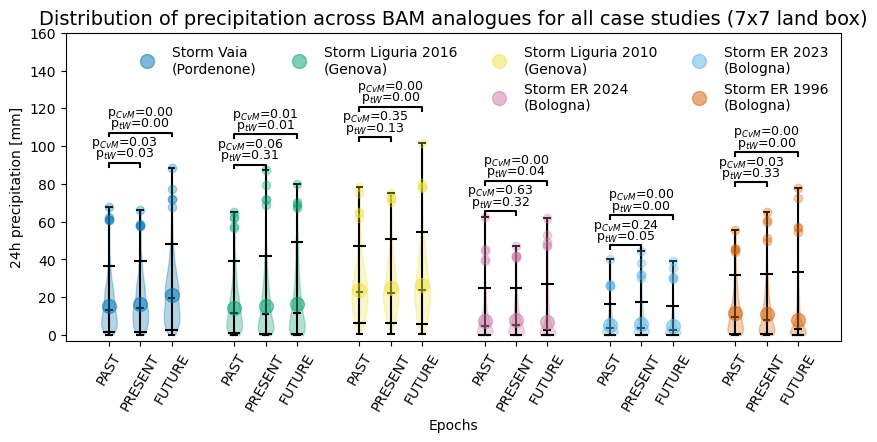

In [7]:
# Plot violin plots per epoch, once per ensemble size

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
ax.set_title(f"Distribution of precipitation across BAM analogues for all case studies (7x7 land box)", fontsize=14)

# Violin plot setup
list_epoch_str = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]

for i in range(tot_events):
    name_event = fanPM.get_storm_name(list_nodes[i], list_events[i])
    town_event = town_events[i]
    # Get the data for the current epoch and ensemble size
    list_reg_precip = list_ds_town[i*no_epochs:(i+1)*no_epochs]
    # Plot the violin for the current epoch and ensemble size
    reg_precip_clean = [x[~np.isnan(x)]*factor for x in list_reg_precip]
    # Plot violin
    violin = ax.violinplot(reg_precip_clean, positions=1+i*4+np.arange(no_epochs), showmeans=False, showmedians=True, showextrema=True)
    for pc in violin['bodies']:
        pc.set_facecolor(color_events[i])   # your color
        pc.set_edgecolor(color_events[i])
        pc.set_alpha(0.3)
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        violin[partname].set_edgecolor('black')
    # Plot the mean precipitation for the epoch
    plot_label = f'{name_event}\n({town_event})'
    ax.plot(1+i*4+np.arange(no_epochs), [np.mean(reg_precip_clean[j]) for j in range(len(reg_precip_clean))], marker='o', color=color_events[i], markersize=10, label=plot_label, linewidth=0, alpha=0.5)

    # Plot the 5 top values as stars
    for j in range(no_epochs):
        top5_values = np.sort(reg_precip_clean[j])[-5:]
        ax.plot(np.full(top5_values.shape, 1 + i*4 + j), top5_values, marker='o', color=color_events[i], markersize=6, linewidth=0, alpha=0.3)
        p5, p95 = np.percentile(reg_precip_clean[j], [5, 95])
        ax.hlines([p5, p95], xmin=1 + i*4 + j -0.2, xmax=1 + i*4 + j + 0.2, colors='k', alpha=1)

    # Add p-value
    # Get x positions of the two violins
    x1 = 1 + i*4 + 0              # first violin position
    x2 = 1 + i*4 + 1              # second violin position
    x3 = 1 + i*4 + 2              # third violin position
    # y separation
    y_sep = 16
    y_sep_fac = 6
    y_max = max([np.max(reg_precip_clean[j]) for j in range(no_epochs)])  # highest point for vertical placement
    # Draw a bracket line
    ax.plot([x1, x1, x2, x2], [y_max+1, y_max+3, y_max+3, y_max+1], color="black")
    ax.plot([x1, x1, x3, x3], [y_max+1+y_sep, y_max+3+y_sep, y_max+3+y_sep, y_max+1+y_sep], color="black")
    # Add the p-value text above
    for istat in range(len(stat_tests)):
        stat_name = stat_tests[istat]
        p_past = list_stats_pastpresent[i][istat,1]
        p_future = list_stats_pastfuture[i][istat,1]
        ax.text((x1+x2)/2, y_max+3.5+istat*y_sep_fac, f"p$_{{{stat_name}}}$={p_past:.2f}", ha="center", va="bottom", fontsize=9, color="black")
        ax.text(x2, y_max+3.5+y_sep+istat*y_sep_fac, f"p$_{{{stat_name}}}$={p_future:.2f}", ha="center", va="bottom", fontsize=9, color="black")
# Ticks and labels
ax.set_xticks(range(1, tot_events*(no_epochs + 1)))
list_epoch_ticks = []
xticks = []
for i in range(tot_events):
    xticks.extend([1+i*4+j for j in range(no_epochs)])
    list_epoch_ticks.extend(list_epoch_names)
ax.set_ylim(-3,160)
ax.set_xticks(xticks)
ax.set_xticklabels(list_epoch_ticks, rotation=60)
ax.set_xlabel('Epochs')
ax.set_ylabel('24h precipitation [mm]')

# legend
handles, labels = plt.gca().get_legend_handles_labels()
# Create 2 invisible handles (for the empty spots)
empty = Line2D([], [], linestyle='none', marker=None, alpha=0)
handles = handles[:1] + [empty] + handles[1:2] + [empty] + handles[2:]
labels  = labels[:1]  + ['']  +  labels[1:2] + ['']    + labels[2:]
ax.legend(handles, labels, ncol=4, frameon=False, loc='upper right') 
plt.show()

# Save the figure
fig.savefig(f"{fig_dir}{varname}_mask-mean_towns_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_{no_membs}membs.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{fig_dir}{varname}_mask-mean_towns_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_{no_membs}membs.pdf", bbox_inches='tight')

### Plot RMSE per event

In [8]:
# Parameters
# Variable
varname = 'pr'

# qtl
qtl_LE_str = '99pct'

# List events
list_nodes = [1,3,3,5,5,6]
list_events = [1,3,8,4,23,19]
tot_events = len(list_nodes)
town_events = ['Pordenone', 'Genova', 'Genova','Bologna', 'Bologna', 'Bologna']
color_events = ['#0072B2', '#009E73', '#F0E442', '#CC79A7', '#56B4E9', '#D55E00']
letters_events = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)
list_epoch_names = ['PAST', 'PRESENT', 'FUTURE']
list_str_year_range = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]
ind_1 = 0
ind_2 = 1

# Color_sign
sign_names = ['Pos', 'Neg']
sign_colors = ['red', 'blue']

# List of ensemble sizes (by no members considered)
no_membs = 49

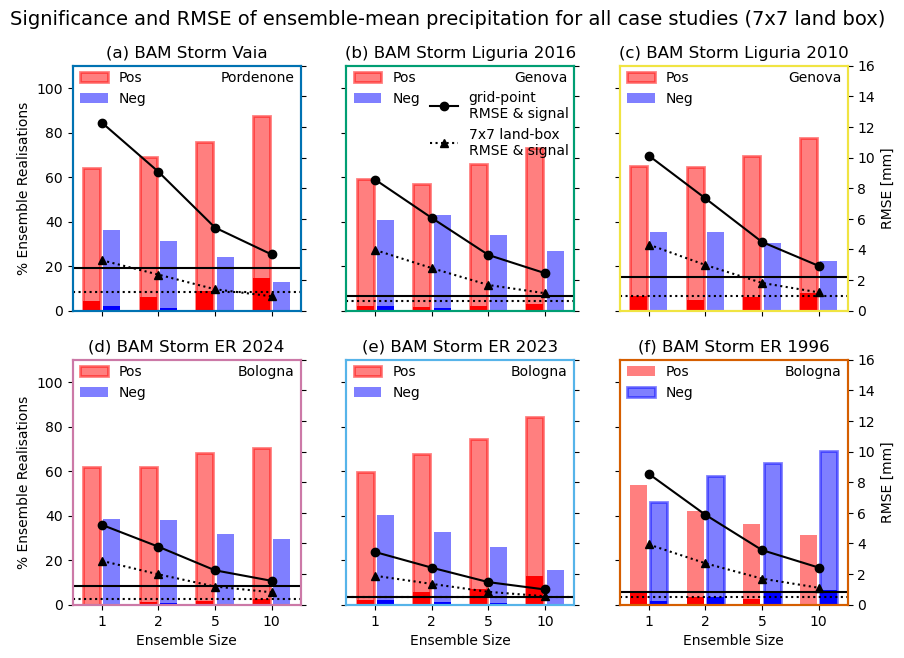

In [9]:
# Fig of 3 col and 2 lines
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 7), sharex=True, sharey=True)
axs = axs.ravel()
fig.suptitle(f"Significance and RMSE of ensemble-mean precipitation for all case studies (7x7 land box)", fontsize=14, y=0.96)

width = 0.3  # width of the bars

for ie in range(len(list_events)):
    no_node = list_nodes[ie]
    no_event = list_events[ie]
    name_event = fanPM.get_storm_name(no_node, no_event)
    town_event = town_events[ie]
    color_event = color_events[ie]
    letter_event = letters_events[ie]
    str_event_BAM = f'BAM-node{no_node}-extreme{no_event}-alertregions'

    # Get rmse for ind_2 vs ind_1 precipitation
    rmse = pd.read_csv(f"{pr_mask_dir}towns/rmse_ens-mean_{town_event}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_1-2-5-10-49membs.csv")
    ens_sizes = rmse['Ensemble Size']
    no_sizes = len(ens_sizes)
    rmse_town = rmse['Town grid-point']
    rmse_town_extended_land = rmse['Town 7x7 Land Box']
    # Get true difference ind_2 - ind_1 precipitation
    true_diff = pd.read_csv(f"{pr_mask_dir}towns/diff_ens-mean_{town_event}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_49membs.csv")
    diff_town = true_diff['Town grid-point'][0]
    diff_town_extended_land = true_diff['Town 7x7 Land Box'][0]
    # Get fractions per sign
    sign = pd.read_csv(f"{pr_mask_dir}towns/sign-frac_ens-mean_{town_event}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_1-2-5-10-49membs.csv")
    sign_town = np.array([list(eval(t)) for t in sign['Town grid-point']], dtype=np.float64)
    sign_town_extended_land = np.array([list(eval(t)) for t in sign['Town 7x7 Land Box']], dtype=np.float64)
    # Get significant fraction per sign
    significance = pd.read_csv(f"{pr_mask_dir}towns/significance-frac_ens-mean_{town_event}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_1-2-5-10-49membs.csv")
    significance_town = np.array([list(eval(t)) for t in significance['Town grid-point']], dtype=np.float64)
    significance_town_extended_land = np.array([list(eval(t)) for t in significance['Town 7x7 Land Box']], dtype=np.float64)

    # Plot histograms

    for isign in range(2):
        x = np.arange(no_sizes) + (isign - 0.5) * width*1.2
        edgecolor = [sign_colors[isign] if (diff_town_extended_land>0 and isign==0) or (diff_town_extended_land<0 and isign==1) else "none"]
        # total fraction (pos/neg split)
        if edgecolor[0] != "none":
            axs[ie].bar(x, sign_town_extended_land[:,isign]*100, width=width,
                   label=sign_names[isign] , color=sign_colors[isign], alpha=.5,
                   edgecolor=edgecolor, linewidth=2)
        else:
            axs[ie].bar(x, sign_town_extended_land[:,isign]*100, width=width,
                   label=sign_names[isign] , color=sign_colors[isign], alpha=.5)

        # overlay significant fraction
        axs[ie].bar(x, significance_town_extended_land[:,isign]*100, width=width,
               color=sign_colors[isign], alpha=1)

    # Plot rmse for the town grid-point and the 7x7 land box
    axs2 = axs[ie].twinx()
    x = np.arange(no_sizes)
    axs2.plot(x, rmse_town, label=f'grid-point\nRMSE & signal', color='k', marker='o')
    axs2.plot(x, rmse_town_extended_land, label=f'7x7 land-box\nRMSE & signal', color='k', marker='^', linestyle=':')
    axs2.axhline(y=np.abs(diff_town), color='k')
    axs2.axhline(y=np.abs(diff_town_extended_land), color='k', linestyle=':')

    # spine color
    for spine in axs[ie].spines.values():
        spine.set_color(color_event)
        spine.set_linewidth(1.5)
    for spine in axs2.spines.values():
        spine.set_color(color_event)
        spine.set_linewidth(1.5)

    axs[ie].set_ylim(0, 110)
    axs2.set_ylim(0, 16)
    axs[ie].set_title(f'{letter_event} BAM {name_event}', fontsize=12)
    axs[ie].text(3.4,103, town_event, fontsize=10, ha='right')
    axs[ie].set_xlabel('Ensemble Size')
    axs[ie].set_ylabel("% Ensemble Realisations")
    if (ie-2)%3==0: 
        axs2.set_ylabel('RMSE [mm]')
    else:
        axs2.set_yticklabels([])
    axs[ie].set_xticks(x)
    axs[ie].set_xticklabels(ens_sizes)
    axs[ie].legend(loc='upper right', frameon=False, ncol=1, bbox_to_anchor=(.38, 1.03))
    if ie==1:
        axs2.legend(loc='upper right', frameon=False, ncol=1, bbox_to_anchor=(1.03, 0.95))
    # remove x label when not in last row
    if ie < 3:
        axs[ie].set_xlabel('')
    # remove y label when not in first column
    if ie % 3 != 0:
        axs[ie].set_ylabel('')

# # Save the figure
fig.savefig(f"{fig_dir}{varname}_significance-rmse_towns_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_1-2-5-10membs.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{fig_dir}{varname}_significance-rmse_towns_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_1-2-5-10membs.pdf", bbox_inches='tight')

In [15]:
sign_town

array(['(np.float64(0.5), np.float64(0.5))',
       '(np.float64(0.59), np.float64(0.41))',
       '(np.float64(0.71), np.float64(0.29))',
       '(np.float64(0.75), np.float64(0.25))'], dtype=object)

In [17]:
# Convert sign_town tuples into a 2D numpy array
sign_town_array = np.array([list(eval(t)) for t in sign_town], dtype=np.float64)
print(sign_town_array.shape)  


(4, 2)
